# 진주시 도로구간 시각화 및 25m 포인트 생성

`(도로명주소)도로구간_경남/TL_SPRD_MANAGE_48_202605.shp`에서 진주시(`SIG_CD = 48170`) 도로구간 중 도로 클래스 `3: 로`, `4: 길`만 추출해 단색으로 시각화하고, 도로 라인 위에 25m 간격 포인트를 생성합니다.

In [23]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import LineString, MultiLineString

# 한글 폰트가 설치된 환경에서는 한글 제목/범례가 정상 표시됩니다.
plt.rcParams["font.family"] = ["NanumGothic", "Malgun Gothic", "AppleGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

In [24]:
ROAD_SHP_CANDIDATES = [
    Path("(도로명주소)도로구간_경남") / "TL_SPRD_MANAGE_48_202605.shp",
    Path("Data") / "(도로명주소)도로구간_경남" / "TL_SPRD_MANAGE_48_202605.shp",
]
ROAD_SHP = next((path for path in ROAD_SHP_CANDIDATES if path.exists()), None)
if ROAD_SHP is None:
    raise FileNotFoundError("TL_SPRD_MANAGE_48_202605.shp 파일을 찾을 수 없습니다.")

JINJU_SIG_CD = "48170"
INCLUDED_ROAD_CLASSES = {"3", "4"}  # 3: 로, 4: 길

roads = gpd.read_file(ROAD_SHP, encoding="cp949")

print(f"도로구간 파일: {ROAD_SHP}")
print(f"전체 도로구간 수: {len(roads):,}")
print(f"원본 좌표계: {roads.crs}")
display(roads.head())

도로구간 파일: Data/(도로명주소)도로구간_경남/TL_SPRD_MANAGE_48_202605.shp
전체 도로구간 수: 88,721
원본 좌표계: EPSG:5179


,ALWNC_DE,ALWNC_RESN,BSI_INT,ENG_RN,MVMN_DE,MVMN_RESN,MVM_RES_CD,NTFC_DE,OPERT_DE,RBP_CN,...,RDS_MAN_NO,REP_CN,RN,RN_CD,ROAD_BT,ROAD_LT,ROA_CLS_SE,SIG_CD,WDR_RD_CD,geometry
0,20091130,봉곡로의 기초번호를 이용한 길,20,Bonggok-ro 120beon-gil,20141030,"광역도로 정비 및 부여사유, 부여방식 정비",90,20091130,20141030233631,봉곡동 502-22도,...,4,봉곡동 52-22도,봉곡로120번길,4781266,8.0,343.0,4,48121,3,"LINESTRING (1106483.813 1695216.321, 1106454.7..."
1,20091130,사림로의 기초번호를 이용한 길,20,Sarim-ro 158beon-gil,20141030,"광역도로 정비 및 부여사유, 부여방식 정비",90,20091130,20141030233631,사림동 501-15도,...,5,사림동 51-22도,사림로158번길,4781294,8.0,300.0,4,48121,3,"LINESTRING (1107772.685 1694633.71, 1107710.73..."
2,20091130,봉곡로의 기초번호를 이용한 길,20,Bonggok-ro 64beon-gil,20141030,"광역도로 정비 및 부여사유, 부여방식 정비",90,20091130,20141030233632,봉곡동 502-14도,...,6,봉곡동 52-15도,봉곡로64번길,4781277,8.0,142.0,4,48121,3,"LINESTRING (1106107.626 1695491.075, 1106106.5..."
3,20091130,창이대로의 기초번호를 이용한 길,20,Changi-daero 409beon-gil,20141030,"광역도로 정비 및 부여사유, 부여방식 정비",90,20091130,20141030233632,사림동 501-26도,...,7,사림동 51-28도,창이대로409번길,4781672,6.0,350.0,4,48121,3,"LINESTRING (1107482.264 1694741.669, 1107512.7..."
4,20091130,봉곡로의 기초번호를 이용한 길,20,Bonggok-ro 123beon-gil,20141030,"광역도로 정비 및 부여사유, 부여방식 정비",90,20091130,20141030233635,봉곡동 502-36도,...,8,봉곡동 52-34도,봉곡로123번길,4781267,8.0,370.0,4,48121,3,"LINESTRING (1106487.273 1695170.887, 1106498.1..."


In [25]:
jinju_all_roads = roads.loc[roads["SIG_CD"].astype(str).eq(JINJU_SIG_CD)].copy()
jinju_all_roads["ROA_CLS_SE"] = jinju_all_roads["ROA_CLS_SE"].astype(str)

jinju_roads = jinju_all_roads.loc[jinju_all_roads["ROA_CLS_SE"].isin(INCLUDED_ROAD_CLASSES)].copy()

if jinju_roads.empty:
    raise ValueError(f"SIG_CD={JINJU_SIG_CD}에서 도로 클래스 3, 4에 해당하는 도로구간이 없습니다.")

summary = pd.DataFrame(
    {
        "항목": ["시각화 대상 도로구간 수", "전체 진주시 도로구간 수", "총 연장(km)", "평균 도로폭(m)", "좌표계"],
        "값": [
            f"{len(jinju_roads):,}",
            f"{len(jinju_all_roads):,}",
            f"{jinju_roads['ROAD_LT'].sum() / 1000:,.1f}",
            f"{jinju_roads['ROAD_BT'].mean():,.1f}",
            str(jinju_roads.crs),
        ],
    }
)

display(summary)
display(jinju_roads["ROA_CLS_SE"].value_counts().sort_index().rename("도로 클래스별 구간 수"))
display(jinju_roads[["SIG_CD", "RN", "RN_CD", "ROAD_LT", "ROAD_BT", "ROA_CLS_SE", "geometry"]].head())

,항목,값
0,시각화 대상 도로구간 수,"8,671"
1,전체 진주시 도로구간 수,"8,677"
2,총 연장(km),"10,585.1"
3,평균 도로폭(m),4.2
4,좌표계,EPSG:5179


ROA_CLS_SE
3    1971
4    6700
Name: 도로 클래스별 구간 수, dtype: int64

,SIG_CD,RN,RN_CD,ROAD_LT,ROAD_BT,ROA_CLS_SE,geometry
10543,48170,진마대로,2332002,35809.0,20.0,3,"LINESTRING (1055353.344 1685038.791, 1055524.4..."
10544,48170,남산길,4796251,2123.0,8.0,4,"LINESTRING (1071148.779 1683571.798, 1071163.5..."
10545,48170,일사로,3019017,8732.0,8.0,3,"LINESTRING (1070893.313 1682100.508, 1070879.9..."
10546,48170,문산로,3019013,9727.0,8.0,3,"LINESTRING (1065712.98 1680130.522, 1065688.75..."
10547,48170,내동로,3332012,3596.0,12.0,3,"LINESTRING (1051912.063 1684898.206, 1051932.4..."


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.

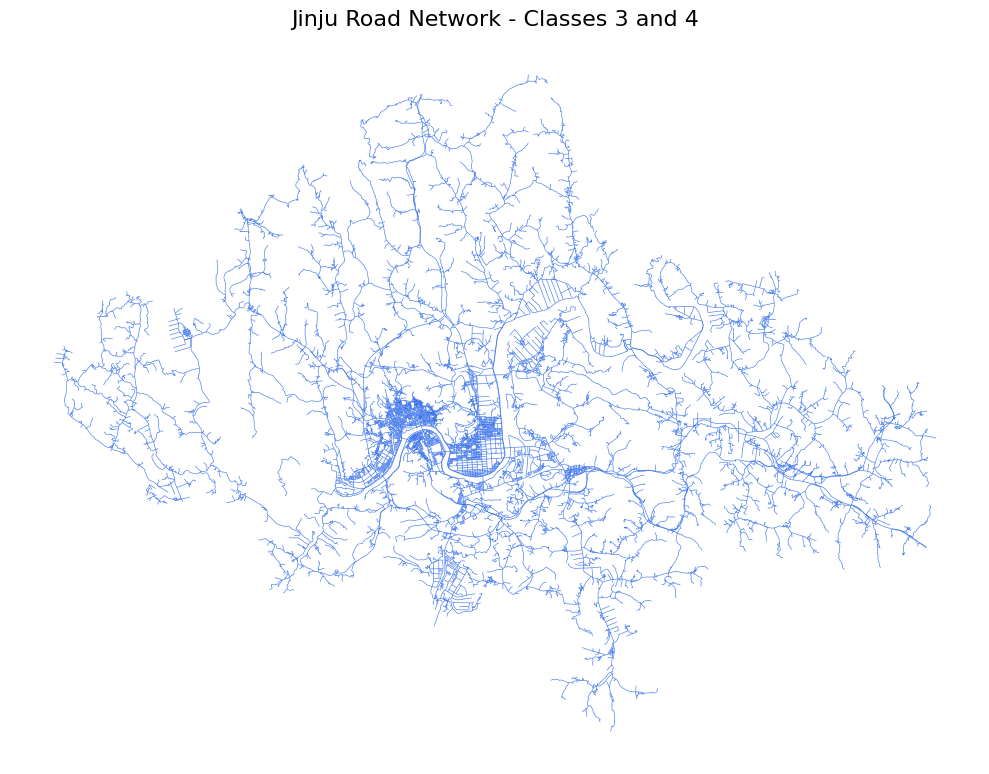

In [26]:
fig, ax = plt.subplots(figsize=(10, 10))

jinju_roads.plot(
    ax=ax,
    linewidth=0.45,
    color="#2563eb",
    alpha=0.85,
)

ax.set_title("Jinju Road Network - Classes 3 and 4", fontsize=16, pad=12)
ax.set_axis_off()
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## 진주시 도로 25m 간격 포인트 생성

현재 도로 데이터 좌표계는 EPSG:5179이므로 거리 단위는 미터입니다. 아래 코드는 도로 클래스 `3: 로`, `4: 길` 라인 위에 25m 간격 포인트를 생성합니다.

In [27]:
def create_points_along_line(geom, distance=25):
    points = []

    if geom is None or geom.is_empty:
        return points

    if isinstance(geom, LineString):
        lines = [geom]
    elif isinstance(geom, MultiLineString):
        lines = list(geom.geoms)
    else:
        return points

    for line in lines:
        distances = list(range(0, int(line.length) + 1, distance))
        if not distances or distances[-1] < line.length:
            distances.append(line.length)

        points.extend(line.interpolate(d) for d in distances)

    return points


point_rows = []

for road_idx, row in jinju_roads.reset_index(drop=True).iterrows():
    road_points = create_points_along_line(row.geometry, distance=25)
    for point_seq, point in enumerate(road_points):
        point_rows.append(
            {
                "POINT_ID": len(point_rows),
                "ROAD_IDX": road_idx,
                "POINT_SEQ": point_seq,
                "RN": row["RN"],
                "RN_CD": row["RN_CD"],
                "ROAD_LT": row["ROAD_LT"],
                "ROAD_BT": row["ROAD_BT"],
                "ROA_CLS_SE": row["ROA_CLS_SE"],
                "geometry": point,
            }
        )

points_25m_gdf = gpd.GeoDataFrame(point_rows, geometry="geometry", crs=jinju_roads.crs)

print(f"생성된 25m 간격 포인트 수: {len(points_25m_gdf):,}")
display(points_25m_gdf.head())

생성된 25m 간격 포인트 수: 109,795


,POINT_ID,ROAD_IDX,POINT_SEQ,RN,RN_CD,ROAD_LT,ROAD_BT,ROA_CLS_SE,geometry
0,0,0,0,진마대로,2332002,35809.0,20.0,3,POINT (1055353.344 1685038.791)
1,1,0,1,진마대로,2332002,35809.0,20.0,3,POINT (1055375.254 1685026.752)
2,2,0,2,진마대로,2332002,35809.0,20.0,3,POINT (1055397.165 1685014.714)
3,3,0,3,진마대로,2332002,35809.0,20.0,3,POINT (1055419.075 1685002.675)
4,4,0,4,진마대로,2332002,35809.0,20.0,3,POINT (1055440.986 1684990.636)


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.

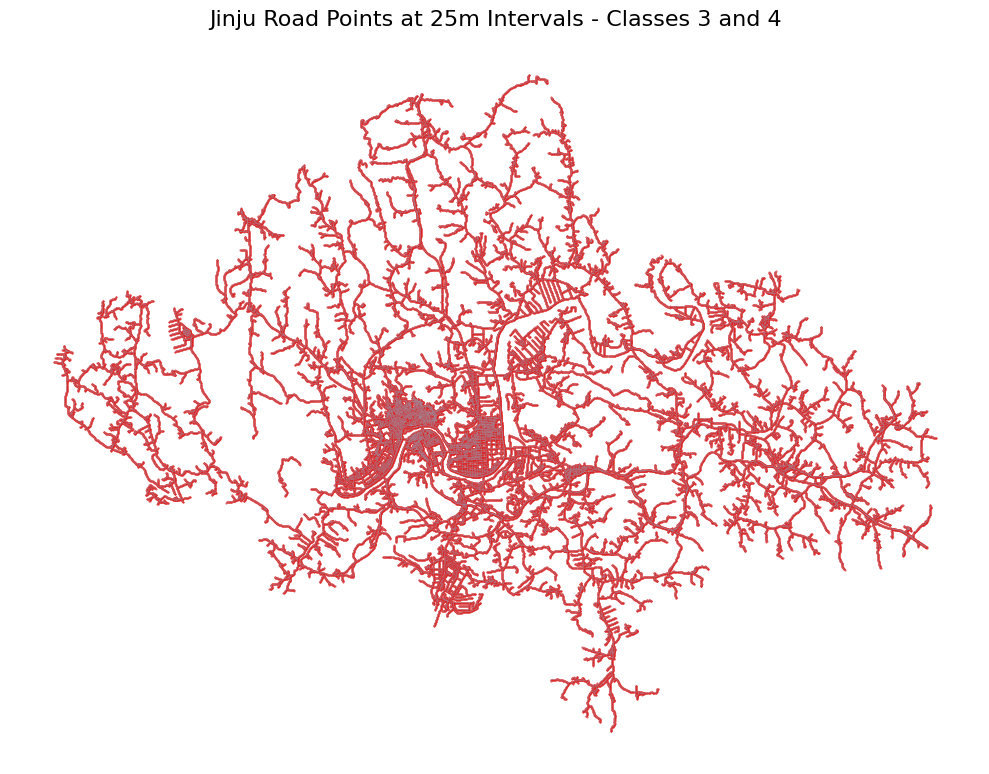

In [28]:
fig, ax = plt.subplots(figsize=(10, 10))

jinju_roads.plot(
    ax=ax,
    linewidth=0.35,
    color="#94a3b8",
    alpha=0.7,
)

points_25m_gdf.plot(
    ax=ax,
    markersize=0.25,
    color="#dc2626",
    alpha=0.75,
)

ax.set_title("Jinju Road Points at 25m Intervals - Classes 3 and 4", fontsize=16, pad=12)
ax.set_axis_off()
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## 25m 포인트별 50m 버퍼 생성

`points_25m_gdf`의 각 포인트를 중심으로 반경 50m 버퍼를 생성합니다. EPSG:5179 좌표계는 미터 단위이므로 `buffer(50)`을 사용합니다.

In [29]:
BUFFER_DISTANCE_M = 50

point_buffers_50m_gdf = points_25m_gdf.copy()
point_buffers_50m_gdf["geometry"] = point_buffers_50m_gdf.geometry.buffer(BUFFER_DISTANCE_M)

print(f"생성된 50m 버퍼 수: {len(point_buffers_50m_gdf):,}")
display(point_buffers_50m_gdf.head())

생성된 50m 버퍼 수: 109,795


,POINT_ID,ROAD_IDX,POINT_SEQ,RN,RN_CD,ROAD_LT,ROAD_BT,ROA_CLS_SE,geometry
0,0,0,0,진마대로,2332002,35809.0,20.0,3,"POLYGON ((1055403.344 1685038.791, 1055403.103..."
1,1,0,1,진마대로,2332002,35809.0,20.0,3,"POLYGON ((1055425.254 1685026.752, 1055425.014..."
2,2,0,2,진마대로,2332002,35809.0,20.0,3,"POLYGON ((1055447.165 1685014.714, 1055446.924..."
3,3,0,3,진마대로,2332002,35809.0,20.0,3,"POLYGON ((1055469.075 1685002.675, 1055468.834..."
4,4,0,4,진마대로,2332002,35809.0,20.0,3,"POLYGON ((1055490.986 1684990.636, 1055490.745..."


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'AppleGothic' not found.

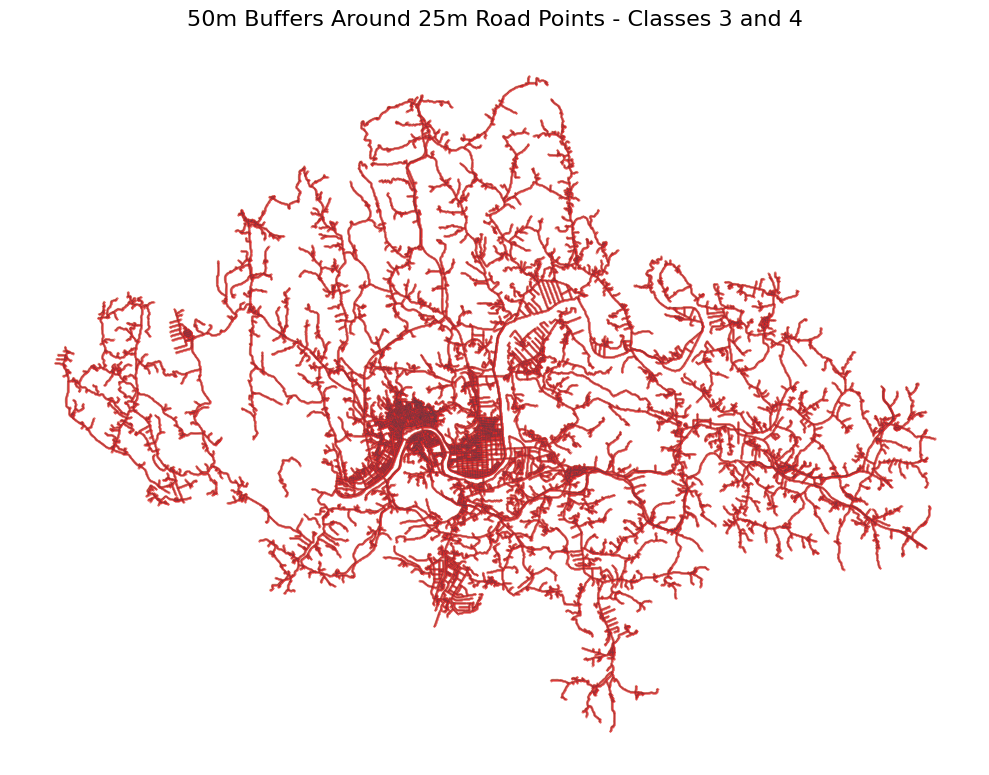

In [30]:
fig, ax = plt.subplots(figsize=(10, 10))

point_buffers_50m_gdf.plot(
    ax=ax,
    color="#f97316",
    alpha=0.12,
    edgecolor="none",
)

jinju_roads.plot(
    ax=ax,
    linewidth=0.25,
    color="#334155",
    alpha=0.75,
)

points_25m_gdf.plot(
    ax=ax,
    markersize=0.15,
    color="#dc2626",
    alpha=0.6,
)

ax.set_title("50m Buffers Around 25m Road Points - Classes 3 and 4", fontsize=16, pad=12)
ax.set_axis_off()
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## Feature 추가 함수 정의

최종 CSV에 들어갈 컬럼을 함수 단위로 추가합니다. 새 feature를 추가할 때는 `add_*` 함수를 만들고 최종 저장 셀에서 순서대로 호출하면 됩니다.

In [31]:
ACCIDENT_CSV = Path("Data/jinju_old_pedestrian_individual_accidents_2020_2025.csv")
NODELINK_SHP = Path("Data/ITS_node_link/MOCT_LINK.shp")
OUTPUT_JOIN_CSV = Path("Data/jinju_road_points.csv")


def make_base_point_df(points_gdf):
    """POINT_ID별 기본 좌표 컬럼을 생성합니다."""
    point_coords_wgs84 = points_gdf[["POINT_ID", "geometry"]].to_crs(epsg=4326).copy()
    point_coords_wgs84["경도"] = point_coords_wgs84.geometry.x
    point_coords_wgs84["위도"] = point_coords_wgs84.geometry.y

    return point_coords_wgs84[["POINT_ID", "위도", "경도"]]


def add_accident_risk(final_df, points_gdf, point_buffers_gdf, accident_csv):
    """50m 버퍼 내 고령보행자 사고를 집계해 위험도 컬럼을 추가합니다."""
    accidents_df = pd.read_csv(accident_csv, encoding="utf-8-sig")

    required_cols = ["x_crdnt", "y_crdnt", "dprs_cnt", "sep_cnt", "slp_cnt"]
    missing_cols = [col for col in required_cols if col not in accidents_df.columns]
    if missing_cols:
        raise ValueError(f"사고 데이터에 필요한 컬럼이 없습니다: {missing_cols}")

    for col in required_cols:
        accidents_df[col] = pd.to_numeric(accidents_df[col], errors="coerce")

    accidents_df = accidents_df.dropna(subset=["x_crdnt", "y_crdnt"]).copy()

    accident_points_gdf = gpd.GeoDataFrame(
        accidents_df,
        geometry=gpd.points_from_xy(accidents_df["x_crdnt"], accidents_df["y_crdnt"]),
        crs=points_gdf.crs,
    )

    if accident_points_gdf.crs != point_buffers_gdf.crs:
        accident_points_gdf = accident_points_gdf.to_crs(point_buffers_gdf.crs)

    # 한 사고가 여러 POINT_ID의 50m 버퍼에 들어가면 각 POINT_ID에 각각 집계됩니다.
    joined_accidents = gpd.sjoin(
        accident_points_gdf[["dprs_cnt", "sep_cnt", "slp_cnt", "geometry"]],
        point_buffers_gdf[["POINT_ID", "geometry"]],
        how="inner",
        predicate="within",
    )

    accident_summary = (
        joined_accidents.groupby("POINT_ID", as_index=False)
        .agg(
            사고건수=("POINT_ID", "size"),
            사망자수=("dprs_cnt", "sum"),
            중상자수=("sep_cnt", "sum"),
            경상자수=("slp_cnt", "sum"),
        )
    )

    result_df = final_df.merge(accident_summary, on="POINT_ID", how="left")
    count_cols = ["사고건수", "사망자수", "중상자수", "경상자수"]
    result_df[count_cols] = result_df[count_cols].fillna(0).astype(int)
    result_df["위험도"] = (
        10
        * result_df["사고건수"]
        * (
            result_df["사망자수"]
            + 0.1168 * result_df["중상자수"]
            + 0.0068 * result_df["경상자수"]
        )
    )

    print(f"사고 데이터 수: {len(accident_points_gdf):,}")
    print(f"버퍼 안에 포함된 사고-포인트 매칭 수: {len(joined_accidents):,}")

    return result_df.drop(columns=count_cols)


def add_speed_limit(final_df, points_gdf, nodelink_shp):
    """ITS 표준노드링크 최근접 링크의 MAX_SPD를 제한속도 컬럼으로 추가합니다."""
    # 전국 링크 전체를 최근접 결합하면 무거우므로, 먼저 진주시 포인트 범위 주변 bbox로 링크를 잘라 읽습니다.
    link_sample_crs = gpd.read_file(nodelink_shp, rows=1, encoding="cp949").crs
    point_bounds_links_crs = gpd.GeoSeries(
        [points_gdf.union_all().envelope],
        crs=points_gdf.crs,
    ).to_crs(link_sample_crs).total_bounds

    minx, miny, maxx, maxy = point_bounds_links_crs
    bbox_buffer_m = 1000
    link_bbox = (minx - bbox_buffer_m, miny - bbox_buffer_m, maxx + bbox_buffer_m, maxy + bbox_buffer_m)

    links_gdf = gpd.read_file(
        nodelink_shp,
        bbox=link_bbox,
        columns=["LINK_ID", "ROAD_NAME", "MAX_SPD", "geometry"],
        encoding="cp949",
    )
    links_gdf = links_gdf.dropna(subset=["MAX_SPD", "geometry"]).copy()
    links_gdf["MAX_SPD"] = pd.to_numeric(links_gdf["MAX_SPD"], errors="coerce")
    links_gdf = links_gdf.dropna(subset=["MAX_SPD"])
    links_gdf = links_gdf.to_crs(points_gdf.crs)

    if links_gdf.empty:
        raise ValueError("진주시 범위 주변에서 ITS 표준노드링크를 찾지 못했습니다.")

    point_speed_df = gpd.sjoin_nearest(
        points_gdf[["POINT_ID", "geometry"]],
        links_gdf[["LINK_ID", "ROAD_NAME", "MAX_SPD", "geometry"]],
        how="left",
        distance_col="link_distance_m",
    )
    point_speed_df = pd.DataFrame(point_speed_df.drop(columns="geometry"))

    # sjoin_nearest는 동거리 최근접 링크가 여러 개이면 POINT_ID가 중복될 수 있습니다.
    # 최종 학습/분석 데이터는 포인트당 1행이어야 하므로 거리, LINK_ID 기준으로 하나만 남깁니다.
    point_speed_df = (
        point_speed_df.sort_values(["POINT_ID", "link_distance_m", "LINK_ID"])
        .drop_duplicates(subset=["POINT_ID"], keep="first")
    )
    point_speed_df = point_speed_df.rename(columns={"MAX_SPD": "제한속도"})
    point_speed_df["제한속도"] = point_speed_df["제한속도"].round().astype("Int64")

    print(f"제한속도 결합 대상 링크 수: {len(links_gdf):,}")

    return final_df.merge(point_speed_df[["POINT_ID", "제한속도"]], on="POINT_ID", how="left")

## 최종 CSV 생성 및 저장

기본 포인트 데이터에 feature 추가 함수들을 순서대로 실행한 뒤 CSV로 저장합니다.

In [32]:
# 25m 포인트
final_join_df = make_base_point_df(points_25m_gdf)

# 위험도 컬럼 추가
final_join_df = add_accident_risk(
    final_df=final_join_df,
    points_gdf=points_25m_gdf,
    point_buffers_gdf=point_buffers_50m_gdf,
    accident_csv=ACCIDENT_CSV,
)

# 제한속도 컬럼 추가
final_join_df = add_speed_limit(
    final_df=final_join_df,
    points_gdf=points_25m_gdf,
    nodelink_shp=NODELINK_SHP,
)


# 마무리
final_join_df = final_join_df[["POINT_ID", "위도", "경도", "제한속도", "위험도"]]

OUTPUT_JOIN_CSV.parent.mkdir(parents=True, exist_ok=True)
final_join_df.to_csv(OUTPUT_JOIN_CSV, index=False, encoding="utf-8-sig")

print(f"저장된 최종 데이터 행 수: {len(final_join_df):,}")
print(f"제한속도 결측 수: {final_join_df['제한속도'].isna().sum():,}")
print(f"CSV 저장: {OUTPUT_JOIN_CSV}")
display(final_join_df.head())

사고 데이터 수: 456
버퍼 안에 포함된 사고-포인트 매칭 수: 5,213
제한속도 결합 대상 링크 수: 25,320
저장된 최종 데이터 행 수: 109,795
제한속도 결측 수: 0
CSV 저장: Data/jinju_road_points.csv


,POINT_ID,위도,경도,제한속도,위험도
0,0,35.159081,128.107776,60,0.0
1,1,35.158971,128.108015,80,0.0
2,2,35.158861,128.108255,80,0.0
3,3,35.158751,128.108495,80,0.0
4,4,35.158642,128.108735,80,0.0
